# Stack Overflow Survey Compensation Model

This notebook takes the cleaned respondent parquet and does the final compensation modeling pass. The point is to compare a sensible range of models, keep the logic visible in the notebook, and end with one compensation benchmark that can then be mirrored in `src/compensation_modeling.py`.


In [1]:
import sys
import warnings
from pathlib import Path


# Robust method to find repo root regardless of where notebook is being run from
def find_root():
    here = Path.cwd().resolve()
    for path in [here, *here.parents]:
        if (path / 'data').exists() and (path / 'src').exists():
            return path
    raise FileNotFoundError('Could not locate repository root from current notebook working directory')


# Add repo root to sys.path so local modules in the `src/` directory can be imported
ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import requests
import seaborn as sns
import shap
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src import comp_clean

# Ignore noisy packages
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Set display parameters to view more and keep easy to view style
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## Notebook Setup

1. Load `clean_core.parquet` and validate the compensation fields
2. Check the compensation sample, country coverage, and inflation-adjusted trends
3. Lock the main window and the narrower side windows
4. Define the local helpers for splits, scoring, feature work, and models
5. Compare the geography baseline, Ridge, and LightGBM setups on the same split
6. Inspect the selected model with SHAP so the main signals are visible
7. Keep a few side branches around to check whether more complexity is actually worth it


## Load Finalized Clean Core

Double checks that `clean_core.parquet` exists and that the compensation fields we need are there before modeling starts.


In [3]:
# Load the cleaned respondent table and make sure the compensation fields look usable
CLEAN_PATH = ROOT / 'data' / 'derived' / 'clean_core.parquet'

clean_core = pd.read_parquet(CLEAN_PATH)
string_cols = clean_core.select_dtypes(include='string').columns
clean_core[string_cols] = clean_core[string_cols].astype(object)
clean_core[string_cols] = clean_core[string_cols].where(pd.notna(clean_core[string_cols]), np.nan)

comp_clean.validate_clean_core(clean_core)

print(CLEAN_PATH)
print(clean_core.shape)
display(clean_core[['survey_year', 'country_clean', 'region', 'comp_real_2025']].sample(5, random_state=42))

/Users/aprilvin/Documents/6211 project/DSBA-6211-Stack-overflow-Survey-Analysis/data/derived/clean_core.parquet
(746226, 105)


,survey_year,country_clean,region,comp_real_2025
660422,2024,Thailand,Asia,NaN
115194,2017,New Zealand,Oceania,NaN
462718,2021,Denmark,Europe,140320.906639
683102,2024,United States,Americas,NaN
116754,2017,United States,Americas,NaN


## Loaded Data QA

Checks missing cleaned countries and regions in the compensation sample, then shows the compensation trend before and after the inflation adjustment.


,window,rows,missing_country_clean,missing_region
0,2019+ core,240269,123,123
1,2021+ tech,160537,58,58
2,2023+ AI,84663,27,27


Remaining raw countries with missing country_clean inside the compensation sample


country
Other Country (Not Listed Above)    85
Nomadic                             70
Other (please specify)              13
I prefer not to say                  6
Name: count, dtype: int64

,survey_year,comp_usd_clean,comp_real_2025
0,2019,56555.0,71218.42
1,2020,54000.0,67172.27
2,2021,55224.0,65612.36
3,2022,66540.0,73199.12
4,2023,75411.0,79677.99
5,2024,67666.0,69446.47
6,2025,80254.0,80254.00


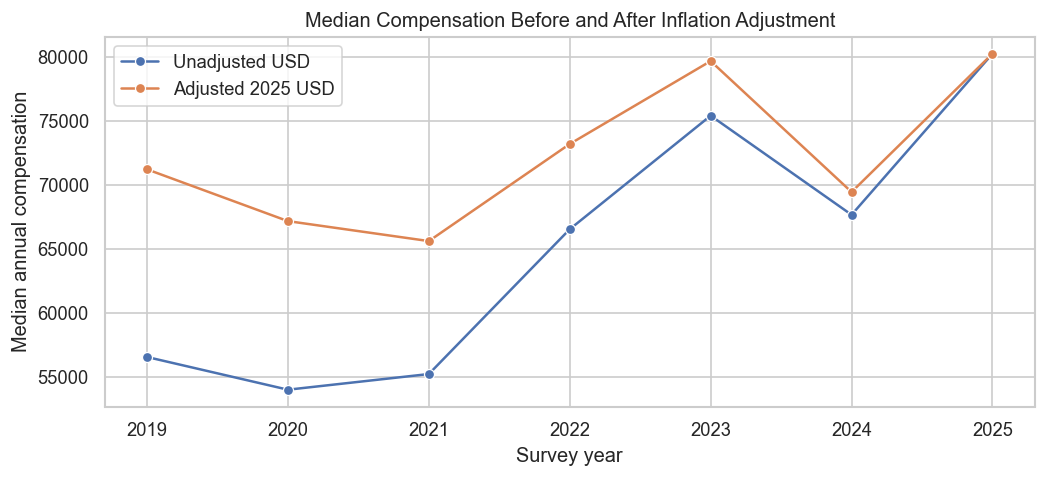

In [4]:
# Builds DataFrame defining windows we intend to use and the missing countries and regions in each
country_qa = pd.DataFrame([
    {
        'window': '2019+ core',
        'rows': int(clean_core['is_comp_model_sample'].sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_sample'], 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_sample'], 'region'].isna().sum())
    },
    {
        'window': '2021+ tech',
        'rows': int((clean_core['is_comp_model_sample'] & clean_core['survey_year'].ge(2021)).sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_sample'] & clean_core['survey_year'].ge(2021), 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_sample'] & clean_core['survey_year'].ge(2021), 'region'].isna().sum())
    },
    {
        'window': '2023+ AI',
        'rows': int((clean_core['is_comp_model_sample'] & clean_core['survey_year'].ge(2023)).sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_sample'] & clean_core['survey_year'].ge(2023), 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_sample'] & clean_core['survey_year'].ge(2023), 'region'].isna().sum())
    }
])
display(country_qa)

print('Remaining raw countries with missing country_clean inside the compensation sample')
display(clean_core.loc[clean_core['is_comp_analysis_sample'] & clean_core['country_clean'].isna(), 'country'].value_counts().head(15))

# Median compensation per year, before and after inflation adjustment
median_comp = (
    clean_core.loc[clean_core['is_comp_model_sample']]
    .groupby('survey_year')[['comp_usd_clean', 'comp_real_2025']]
    .median()
    .reset_index()
)
display(median_comp.round(2))

# Trendlines for compensation
plt.figure(figsize=(10, 4))
sns.lineplot(data=median_comp, x='survey_year', y='comp_usd_clean', marker='o', label='Unadjusted USD')
sns.lineplot(data=median_comp, x='survey_year', y='comp_real_2025', marker='o', label='Adjusted 2025 USD')
plt.title('Median Compensation Before and After Inflation Adjustment')
plt.xlabel('Survey year')
plt.ylabel('Median annual compensation')
plt.legend()
plt.show()

## Final Window Choice

The main model should use the widest window that still has solid feature coverage, so the core window stays at `2019+`. The later windows stay in as side analyses for the richer remote, tech, learning, and AI fields. Since the data is only indexed by survey year, the split also has to stay simple and year-aware: `2025` test, `2024` validation, and the rest as training.


In [5]:
# Limit to rows that have been marked clean for compensation modeling and that have region data
base_model_df = clean_core.loc[
    clean_core['is_comp_model_sample']
    & clean_core['country_clean'].notna()
    & clean_core['region'].notna()
].copy()
base_model_df['survey_year_str'] = base_model_df['survey_year'].astype(str)

# Define DataFrames for each of the windows we intend to look at
core_df = base_model_df.copy()
tech_df = base_model_df.loc[base_model_df['survey_year'].ge(2021)].copy()
ai_df = base_model_df.loc[base_model_df['survey_year'].ge(2023)].copy()

# Show how many rows we have per window as well as the coverage of major features
window_summary = pd.DataFrame([
    {
        'window': '2019+ core',
        'rows': len(core_df),
        'train_years': '2019-2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(core_df['age_mid'].notna().mean(), 3),
        'experience_share': round(core_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(core_df['country_clean'].notna().mean(), 3),
        'remote_share': round(core_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(core_df['ai_sent'].notna().mean(), 3)
    },
    {
        'window': '2021+ tech',
        'rows': len(tech_df),
        'train_years': '2021-2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(tech_df['age_mid'].notna().mean(), 3),
        'experience_share': round(tech_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(tech_df['country_clean'].notna().mean(), 3),
        'remote_share': round(tech_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(tech_df['ai_sent'].notna().mean(), 3)
    },
    {
        'window': '2023+ AI',
        'rows': len(ai_df),
        'train_years': '2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(ai_df['age_mid'].notna().mean(), 3),
        'experience_share': round(ai_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(ai_df['country_clean'].notna().mean(), 3),
        'remote_share': round(ai_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(ai_df['ai_sent'].notna().mean(), 3)
    }
])

display(window_summary)

,window,rows,train_years,valid_year,test_year,age_share,experience_share,country_share,remote_share,ai_sent_share
0,2019+ core,240146,2019-2023,2024,2025,0.975,0.991,1.0,0.681,0.273
1,2021+ tech,160479,2021-2023,2024,2025,0.997,0.992,1.0,0.728,0.408
2,2023+ AI,84636,2023,2024,2025,0.998,0.994,1.0,0.979,0.773


## Notebook Helper Functions And Feature Sets

This is the one dense section of the notebook. It keeps the feature engineering, scoring, and model helpers in one place so the later comparison cells can stay focused on what changed and what actually helped.


**Useful Constants and Feature Sets**

In [6]:
RANDOM_STATE = 42

# Define target variable names for modeling
COMP_TARGET = 'log_comp_real_2025'
COMP_REAL = 'comp_real_2025'
WINSOR_REAL = 'comp_real_2025_winsor'
WINSOR_TARGET = 'log_comp_real_2025_winsor'

# Define training windows and corresponding validation/test years for each set of features
CORE_WINDOW_YEARS = [2019, 2020, 2021, 2022, 2023]
TECH_WINDOW_YEARS = [2021, 2022, 2023]
AI_WINDOW_YEARS = [2023]
VALID_YEAR = 2024
TEST_YEAR = 2025

# Ridge regression alphas to test for baseline models and comparison to LightGBM performance
RIDGE_ALPHAS = [1.0, 5.0, 10.0, 25.0]
BASELINE_GROUP_SETS = [['country_clean'], ['region'], []]

# Define top N technologies to keep for each category based on overall popularity in the compensation sample
TOP_N_TECH = {
    'language': 15,
    'database': 10,
    'platform': 10
}

# Base LightGBM parameters for initial modeling
DEFAULT_LGB_PARAMS = {
    'objective': 'regression_l1',
    'metric': 'l1',
    'boosting_type': 'gbdt',
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 0.0,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1
}

# LightGBM parameters tuned with Optuna for best model performance
NOTEBOOK_TUNED_LGB_PARAMS = {
    'objective': 'regression_l1',
    'metric': 'l1',
    'boosting_type': 'gbdt',
    'n_estimators': 659,
    'learning_rate': 0.04280768609535672,
    'num_leaves': 104,
    'max_depth': 11,
    'min_child_samples': 22,
    'subsample': 0.6872084049537491,
    'colsample_bytree': 0.7368883480938272,
    'reg_alpha': 9.28733327190043,
    'reg_lambda': 3.8666260444964735e-07,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1
}

LGB_PRESETS = {
    'default': DEFAULT_LGB_PARAMS,
    'tuned': NOTEBOOK_TUNED_LGB_PARAMS
}

# World Bank has a few country names that differ from country_clean and must be mapped
WORLD_BANK_NAME_MAP = {
    'Russian Federation': 'Russia',
    'Turkiye': 'Türkiye',
    'Turkey': 'Türkiye',
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Venezuela, RB': 'Venezuela',
    'Czechia': 'Czech Republic',
    'Slovak Republic': 'Slovakia',
    'Hong Kong SAR, China': 'Hong Kong (S.A.R.)',
    'Viet Nam': 'Vietnam'
}

# Geographic regions to focus on for locked geography model fits
FOCUS_GEOS = [
    ('country', 'United States'),
    ('country', 'India'),
    ('region', 'Europe')
]

# Define each categorical and numerical feature set for the core, tech, and AI windows
role_cols = sorted(col for col in base_model_df.columns if col.startswith('role_'))
CORE_CAT = ['survey_year_str', 'region', 'country_clean', 'employment_group', 'education_clean', 'org_size_clean']
CORE_NUM = ['age_mid', 'professional_experience_years', 'language_count', 'database_count', 'platform_count'] + role_cols
TECH_CAT = CORE_CAT.copy()
TECH_NUM = CORE_NUM + ['learn_code_count', 'webframe_count', 'misc_tech_count']
AI_CAT = CORE_CAT + ['remote_group', 'ai_use', 'ai_sent']
AI_NUM = TECH_NUM + ['learn_code_online_count', 'coding_activities_count', 'op_sys_prof_count']

**Splitting and Scoring Functions**

In [7]:
# Reusable function to split any given DataFrame into train, valid, and test sets based on specified years
def split_years(frame, train_years, valid_year, test_year):
    train = frame.loc[frame['survey_year'].isin(train_years)].copy()
    valid = frame.loc[frame['survey_year'] == valid_year].copy()
    test = frame.loc[frame['survey_year'] == test_year].copy()
    return train, valid, test


# Reusable generator function to create rolling origin splits for any given DataFrame based on survey_year
def rolling_origin_splits(frame, min_train_year=2019, final_valid_year=2024):
    years = sorted(year for year in frame['survey_year'].dropna().unique() if year >= min_train_year)
    for valid_year in years:
        if valid_year > final_valid_year:
            continue
        train_years = [year for year in years if year < valid_year]
        if not train_years:
            continue
        train = frame.loc[frame['survey_year'].isin(train_years)].copy()
        valid = frame.loc[frame['survey_year'] == valid_year].copy()
        if len(train) and len(valid):
            yield train_years, valid_year, train, valid


# Reusable scoring function to do a full round of evaluation metrics
def score_predictions(y_true_log, pred_log):
    y_true_real = np.exp(np.asarray(y_true_log, dtype=float))
    pred_real = np.exp(np.asarray(pred_log, dtype=float))
    return {
        'medae_real': median_absolute_error(y_true_real, pred_real),
        'mae_real': mean_absolute_error(y_true_real, pred_real),
        'rmse_real': np.sqrt(mean_squared_error(y_true_real, pred_real)),
        'rmse_log': np.sqrt(mean_squared_error(y_true_log, pred_log)),
        'r2_log': r2_score(y_true_log, pred_log)
    }


# Baseline prediction function, fills missing predictions with hierarchical median of given group, then scores them
def predict_hier_median(train_df, score_df, group_sets, target_col=COMP_REAL):
    pred = pd.Series(np.nan, index=score_df.index, dtype='float64')

    for group_cols in group_sets:
        if not group_cols:
            pred = pred.fillna(train_df[target_col].median())
            continue

        medians = (
            train_df
            .groupby(group_cols, dropna=False)[target_col]
            .median()
            .rename('pred_real')
            .reset_index()
        )
        scored = score_df[group_cols].merge(medians, on=group_cols, how='left')
        pred = pred.fillna(pd.Series(scored['pred_real'].to_numpy(), index=score_df.index))

    pred = pred.fillna(train_df[target_col].median())
    return np.log(pred)


# Scores the baseline models on the holdout test set
def score_holdout_baseline(train_df, valid_df, test_df, group_sets=BASELINE_GROUP_SETS):
    valid_pred = predict_hier_median(train_df, valid_df, group_sets)
    valid_metrics = score_predictions(valid_df[COMP_TARGET], valid_pred)

    train_valid = pd.concat([train_df, valid_df], axis=0)
    test_pred = predict_hier_median(train_valid, test_df, group_sets)
    test_metrics = score_predictions(test_df[COMP_TARGET], test_pred)
    return {
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics
    }


# Helper function to create a result row for easy comparison of different models and windows
def result_row(name, result):
    return {
        'setup': name,
        'valid_medae_real': result['valid_metrics']['medae_real'],
        'test_medae_real': result['test_metrics']['medae_real'],
        'test_rmse_real': result['test_metrics']['rmse_real'],
        'test_r2_log': result['test_metrics']['r2_log']
    }

**Preprocessing Functions**

In [8]:
# Helps convert column data to numerics and coerces non-convertible values to NaN
def coerce_numeric_fields(frame, fields):
    out = frame.copy()
    for field in fields:
        if field in out.columns:
            out[field] = pd.to_numeric(out[field], errors='coerce')
    return out


# Gets the top N most common tech fields from a given column, handles multiple semicolon-separated values
def extract_top_techs(frame, column, n):
    tokens = (
        frame[column]
        .dropna()
        .astype(str)
        .str.split(';')
        .explode()
        .str.strip()
    )
    tokens = tokens.loc[tokens.ne('')]
    return tokens.value_counts().head(n).index.tolist()


# Replaces special characters in tech names with safe alternatives, for flagging
def tech_flag_name(column, tech):
    safe = (
        tech.lower()
        .replace('++', '_plusplus_')
        .replace('+', '_plus_')
        .replace('#', '_sharp_')
        .replace('.', '_dot_')
        .replace('/', '_slash_')
        .replace('&', '_and_')
        .replace(' ', '_')
    )
    safe = ''.join(ch if ch.isalnum() or ch == '_' else '_' for ch in safe)
    safe = '_'.join(part for part in safe.split('_') if part)
    return f'{column}_{safe}'


# Adds binary flag columns for whether each of the top N technologies in each category is mentioned
def add_top_tech_flags(frame, fit_frame, top_n_map=TOP_N_TECH):
    out = frame.copy()
    created = []

    for column, n in top_n_map.items():
        if column not in out.columns or column not in fit_frame.columns:
            continue

        normalized = (
            ';'
            + out[column]
            .fillna('')
            .astype(str)
            .str.replace(r'\s*;\s*', ';', regex=True)
            .str.strip('; ')
            + ';'
        )

        for tech in extract_top_techs(fit_frame, column, n):
            col_name = tech_flag_name(column, tech)
            out[col_name] = normalized.str.contains(f';{tech};', regex=False, na=False).astype(int)
            created.append(col_name)

    return out, created


# Adds winsorized versions of the compensation target based on group-specific thresholds
def add_winsor_targets(frame, fit_frame=None, group_cols=('country_clean',), lower_q=0.01, upper_q=0.99, min_group_size=20):
    out = coerce_numeric_fields(frame, [COMP_REAL])
    fit_source = out if fit_frame is None else coerce_numeric_fields(fit_frame, [COMP_REAL])

    thresholds = (
        fit_source
        .groupby(list(group_cols), dropna=False)[COMP_REAL]
        .agg(
            group_size='size',
            lower=lambda series: series.quantile(lower_q),
            upper=lambda series: series.quantile(upper_q)
        )
        .reset_index()
    )
    thresholds.loc[thresholds['group_size'] < min_group_size, ['lower', 'upper']] = np.nan

    global_lower = fit_source[COMP_REAL].quantile(lower_q)
    global_upper = fit_source[COMP_REAL].quantile(upper_q)

    out = out.merge(thresholds[list(group_cols) + ['lower', 'upper']], on=list(group_cols), how='left')
    out['lower'] = out['lower'].fillna(global_lower)
    out['upper'] = out['upper'].fillna(global_upper)
    out[WINSOR_REAL] = out[COMP_REAL].clip(lower=out['lower'], upper=out['upper'])
    out[WINSOR_TARGET] = np.log(out[WINSOR_REAL])
    return out.drop(columns=['lower', 'upper'])


# Normalizes all columns of a given DataFrame to the appropriate types for categorical and numerical features
def normalize_feature_frame(frame, cat_cols, num_cols):
    out = frame.copy()
    for col in cat_cols:
        out[col] = out[col].astype(object)
        out.loc[out[col].isna(), col] = np.nan
    for col in num_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce').astype(float)
    return out


# Prepares a DataFrame for LightGBM by normalizing types, imputing numericals, and encoding categoricals as categories
def prepare_lgbm_frame(frame, cat_cols, num_cols, target_col):
    out = frame.copy()
    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing').astype('category')

    num_imputer = SimpleImputer(strategy='median')
    out_num = pd.DataFrame(
        num_imputer.fit_transform(out[num_cols]),
        columns=num_cols,
        index=out.index
    )
    out[num_cols] = out_num
    out[target_col] = pd.to_numeric(out[target_col], errors='coerce')
    return out, num_imputer


# Transforms LightGBM model input frame based on the imputer fitted on the training data
def transform_lgbm_frame(frame, cat_cols, num_cols, num_imputer, target_col):
    out = frame.copy()
    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing').astype('category')

    out_num = pd.DataFrame(
        num_imputer.transform(out[num_cols]),
        columns=num_cols,
        index=out.index
    )
    out[num_cols] = out_num
    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce')
    return out

**Core Model Building Functions**

In [9]:
# Sets up a full Pipeline for preprocessing and fitting the Ridge Regression model
def build_ridge_pipe(cat_cols, num_cols):
    prep = ColumnTransformer([
        (
            'cat',
            Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
                ('encode', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=500))
            ]),
            cat_cols
        ),
        (
            'num',
            Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())
            ]),
            num_cols
        )
    ])
    return Pipeline([
        ('prep', prep),
        ('model', Ridge())
    ])


# Fits multiple Ridge models with different alpha values, evaluates on valid set to get best model, then fits the full model and evaluates on the holdout set
def fit_ridge_holdout(train_df, valid_df, test_df, cat_cols, num_cols, alphas=RIDGE_ALPHAS):
    feature_cols = cat_cols + num_cols
    train_df = normalize_feature_frame(train_df, cat_cols, num_cols)
    valid_df = normalize_feature_frame(valid_df, cat_cols, num_cols)
    test_df = normalize_feature_frame(test_df, cat_cols, num_cols)

    pipe = build_ridge_pipe(cat_cols, num_cols)
    trials = []
    best_alpha = None
    best_valid = None

    for alpha in alphas:
        model = clone(pipe)
        model.set_params(model=Ridge(alpha=alpha))
        model.fit(train_df[feature_cols], train_df[COMP_TARGET])
        valid_metrics = score_predictions(valid_df[COMP_TARGET], model.predict(valid_df[feature_cols]))
        trials.append({
            'alpha': alpha,
            **{f'valid_{key}': value for key, value in valid_metrics.items()}
        })
        if best_valid is None or valid_metrics['medae_real'] < best_valid['medae_real']:
            best_valid = valid_metrics
            best_alpha = alpha

    final_model = clone(pipe)
    final_model.set_params(model=Ridge(alpha=best_alpha))
    train_valid = pd.concat([train_df, valid_df], axis=0)
    final_model.fit(train_valid[feature_cols], train_valid[COMP_TARGET])
    test_metrics = score_predictions(test_df[COMP_TARGET], final_model.predict(test_df[feature_cols]))

    return {
        'trials': pd.DataFrame(trials),
        'best_params': {'alpha': best_alpha},
        'model': final_model,
        'feature_cols': feature_cols,
        'valid_metrics': best_valid,
        'test_metrics': test_metrics
    }


# Updates the LightGBM parameters with any custom parameters provided, falling back to defaults for any not specified
def resolve_lgb_params(params=None):
    resolved = dict(DEFAULT_LGB_PARAMS)
    if params is not None:
        resolved.update(params)
    return resolved


# Uses Optuna to tune LightGBM hyperparameters based on performance on the validation set, returns the best parameters found
def tune_lightgbm(train_df, valid_df, cat_cols, num_cols, target_col=COMP_TARGET, base_params=None, n_trials=30, device_type=None):
    base_params = resolve_lgb_params(base_params)
    if device_type:
        base_params['device_type'] = device_type

    train_prepped, num_imputer = prepare_lgbm_frame(train_df, cat_cols, num_cols, target_col)
    valid_prepped = transform_lgbm_frame(valid_df, cat_cols, num_cols, num_imputer, target_col)
    features = cat_cols + num_cols

    def objective(trial):
        params = dict(base_params)
        params.update({
            'n_estimators': trial.suggest_int('n_estimators', 200, 900),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 5, 16),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        })
        model = lgb.LGBMRegressor(**params)
        model.fit(
            train_prepped[features],
            train_prepped[target_col].to_numpy(),
            eval_set=[(valid_prepped[features], valid_prepped[target_col].to_numpy())],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        pred_valid = model.predict(valid_prepped[features], num_iteration=model.best_iteration_)
        return score_predictions(valid_prepped[target_col], pred_valid)['medae_real']

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    best_params = dict(base_params)
    best_params.update(study.best_trial.params)
    return best_params


# Fits a LightGBM model on the training set with early stopping based on the validation set, then fits a final model on the combined train and valid sets and evaluates on the holdout test set
def fit_lightgbm_holdout(train_df, valid_df, test_df, cat_cols, num_cols, target_col=COMP_TARGET, params=None, score_target_col=None, early_stopping_rounds=50):
    score_target_col = target_col if score_target_col is None else score_target_col
    resolved_params = resolve_lgb_params(params)
    features = cat_cols + num_cols

    train_prepped, num_imputer = prepare_lgbm_frame(train_df, cat_cols, num_cols, target_col)
    valid_prepped = transform_lgbm_frame(valid_df, cat_cols, num_cols, num_imputer, target_col)

    early_model = lgb.LGBMRegressor(**resolved_params)
    early_model.fit(
        train_prepped[features],
        train_prepped[target_col].to_numpy(),
        eval_set=[(valid_prepped[features], valid_prepped[target_col].to_numpy())],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
    )
    best_iteration = early_model.best_iteration_ or resolved_params.get('n_estimators', DEFAULT_LGB_PARAMS['n_estimators'])
    valid_pred = early_model.predict(valid_prepped[features], num_iteration=best_iteration)
    valid_metrics = score_predictions(valid_df[score_target_col], valid_pred)

    final_params = dict(resolved_params)
    final_params['n_estimators'] = best_iteration
    final_model = lgb.LGBMRegressor(**final_params)
    full_train_raw = pd.concat([train_df, valid_df], axis=0)
    full_train, full_num_imputer = prepare_lgbm_frame(full_train_raw, cat_cols, num_cols, target_col)
    full_test = transform_lgbm_frame(test_df, cat_cols, num_cols, full_num_imputer, target_col)
    final_model.fit(full_train[features], full_train[target_col].to_numpy())
    test_pred = final_model.predict(full_test[features])
    test_metrics = score_predictions(test_df[score_target_col], test_pred)

    return {
        'model': final_model,
        'best_params': final_params,
        'feature_cols': features,
        'plot_frame': full_test,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics,
        'valid_pred': valid_pred,
        'test_pred': test_pred
    }


# Similar to fit_lightgbm_holgout but adds target variable winsorization
def fit_lightgbm_winsor_holdout(train_df, valid_df, test_df, cat_cols, num_cols, params=None, group_cols=('country_clean',), early_stopping_rounds=50):
    resolved_params = resolve_lgb_params(params)
    train_winsor = add_winsor_targets(train_df, fit_frame=train_df, group_cols=group_cols)
    valid_winsor = add_winsor_targets(valid_df, fit_frame=train_df, group_cols=group_cols)
    features = cat_cols + num_cols

    train_prepped, num_imputer = prepare_lgbm_frame(train_winsor, cat_cols, num_cols, WINSOR_TARGET)
    valid_prepped = transform_lgbm_frame(valid_winsor, cat_cols, num_cols, num_imputer, WINSOR_TARGET)

    early_model = lgb.LGBMRegressor(**resolved_params)
    early_model.fit(
        train_prepped[features],
        train_prepped[WINSOR_TARGET].to_numpy(),
        eval_set=[(valid_prepped[features], valid_prepped[WINSOR_TARGET].to_numpy())],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
    )
    best_iteration = early_model.best_iteration_ or resolved_params.get('n_estimators', DEFAULT_LGB_PARAMS['n_estimators'])
    valid_pred = early_model.predict(valid_prepped[features], num_iteration=best_iteration)
    valid_metrics = score_predictions(valid_winsor[COMP_TARGET], valid_pred)

    full_train_raw = pd.concat([train_df, valid_df], axis=0)
    full_train_winsor = add_winsor_targets(full_train_raw, fit_frame=full_train_raw, group_cols=group_cols)
    full_test_winsor = add_winsor_targets(test_df, fit_frame=full_train_raw, group_cols=group_cols)
    final_params = dict(resolved_params)
    final_params['n_estimators'] = best_iteration
    final_model = lgb.LGBMRegressor(**final_params)
    final_train, full_num_imputer = prepare_lgbm_frame(full_train_winsor, cat_cols, num_cols, WINSOR_TARGET)
    final_test = transform_lgbm_frame(full_test_winsor, cat_cols, num_cols, full_num_imputer, WINSOR_TARGET)
    final_model.fit(final_train[features], final_train[WINSOR_TARGET].to_numpy())
    test_pred = final_model.predict(final_test[features])
    test_metrics = score_predictions(full_test_winsor[COMP_TARGET], test_pred)

    return {
        'model': final_model,
        'best_params': final_params,
        'feature_cols': features,
        'plot_frame': final_test,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics,
        'valid_pred': valid_pred,
        'test_pred': test_pred
    }


# Main function to fit a LightGBM model on a given window with options for top tech flags and winsorization
def fit_window_lightgbm(window_df, train_years, valid_year, test_year, cat_cols, num_cols, params=None, use_top_tech=True, winsor_target=False, top_n_map=TOP_N_TECH):
    train_df, valid_df, test_df = split_years(window_df, train_years, valid_year, test_year)
    tech_flag_cols = []

    if use_top_tech:
        train_df, tech_flag_cols = add_top_tech_flags(train_df, fit_frame=train_df, top_n_map=top_n_map)
        valid_df, _ = add_top_tech_flags(valid_df, fit_frame=train_df, top_n_map=top_n_map)
        test_df, _ = add_top_tech_flags(test_df, fit_frame=train_df, top_n_map=top_n_map)

    final_num_cols = num_cols + tech_flag_cols
    if winsor_target:
        result = fit_lightgbm_winsor_holdout(train_df, valid_df, test_df, cat_cols, final_num_cols, params=params)
    else:
        result = fit_lightgbm_holdout(train_df, valid_df, test_df, cat_cols, final_num_cols, params=params)

    return {
        'train_df': train_df,
        'valid_df': valid_df,
        'test_df': test_df,
        'tech_flag_cols': tech_flag_cols,
        'cat_cols': cat_cols,
        'num_cols': final_num_cols,
        **result
    }


# Helper function to plot SHAP summary plot for a given model result
def plot_shap_summary(result, title, sample_size=2000, max_display=20):
    plot_frame = result['plot_frame']
    if plot_frame.empty:
        print('No rows available for SHAP')
        return

    sample_n = min(sample_size, len(plot_frame))
    shap_frame = plot_frame.sample(sample_n, random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(result['model'])
    shap_values = explainer(shap_frame[result['feature_cols']])
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, shap_frame[result['feature_cols']], max_display=max_display, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

**Experimental Model Functions**

In [10]:
# Creates a basic geographic prediction function based on medians by country and region, first stage of residual modeling
def build_geo_backbone(train_df):
    country_median = train_df.groupby('country_clean')[COMP_REAL].median().rename('pred_country').reset_index()
    region_median = train_df.groupby('region')[COMP_REAL].median().rename('pred_region').reset_index()
    overall = train_df[COMP_REAL].median()

    def predict(frame):
        out = frame[['country_clean', 'region']].copy()
        out = out.merge(country_median, on='country_clean', how='left')
        out = out.merge(region_median, on='region', how='left')
        pred_real = out['pred_country'].fillna(out['pred_region']).fillna(overall)
        return pd.Series(np.log(pred_real.to_numpy()), index=frame.index)

    return predict


# Main function to fit a two-stage LightGBM model where the first stage is a geographic backbone and the second stage models residuals with additional features
def fit_two_stage_lightgbm(train_df, valid_df, test_df, params=None):
    residual_cat = [col for col in CORE_CAT if col not in ['country_clean', 'region']]

    train_with_flags, tech_flag_cols = add_top_tech_flags(train_df, fit_frame=train_df)
    valid_with_flags, _ = add_top_tech_flags(valid_df, fit_frame=train_df)
    residual_num = CORE_NUM + tech_flag_cols

    valid_backbone = build_geo_backbone(train_df)
    train_base_log = valid_backbone(train_df)
    valid_base_log = valid_backbone(valid_df)
    train_with_flags['target_resid'] = train_with_flags[COMP_TARGET] - train_base_log
    valid_with_flags['target_resid'] = valid_with_flags[COMP_TARGET] - valid_base_log

    residual_model = fit_lightgbm_holdout(
        train_with_flags,
        valid_with_flags,
        valid_with_flags,
        residual_cat,
        residual_num,
        target_col='target_resid',
        score_target_col='target_resid',
        params=params
    )
    valid_pred = valid_base_log + residual_model['valid_pred']
    valid_metrics = score_predictions(valid_df[COMP_TARGET], valid_pred)

    train_valid = pd.concat([train_df, valid_df], axis=0)
    train_valid_with_flags, final_tech_flag_cols = add_top_tech_flags(train_valid, fit_frame=train_valid)
    test_with_flags, _ = add_top_tech_flags(test_df, fit_frame=train_valid)
    final_residual_num = CORE_NUM + final_tech_flag_cols

    test_backbone = build_geo_backbone(train_valid)
    train_valid_base_log = test_backbone(train_valid)
    test_base_log = test_backbone(test_df)
    train_valid_with_flags['target_resid'] = train_valid_with_flags[COMP_TARGET] - train_valid_base_log

    final_params = dict(residual_model['best_params'])
    final_features = residual_cat + final_residual_num
    final_train_prepped, final_num_imputer = prepare_lgbm_frame(train_valid_with_flags, residual_cat, final_residual_num, 'target_resid')
    final_test_prepped = transform_lgbm_frame(test_with_flags, residual_cat, final_residual_num, final_num_imputer, 'target_resid')
    final_model = lgb.LGBMRegressor(**final_params)
    final_model.fit(final_train_prepped[final_features], final_train_prepped['target_resid'].to_numpy())
    test_resid_pred = final_model.predict(final_test_prepped[final_features])
    test_pred = test_base_log + test_resid_pred
    test_metrics = score_predictions(test_df[COMP_TARGET], test_pred)

    return {
        'model': final_model,
        'feature_cols': final_features,
        'plot_frame': final_test_prepped,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics
    }


# Grabs the GDP PPP per capita data from the World Bank API for a given year and remaps the country names
def fetch_world_bank_gdp_ppp(year=2022):
    url = f'https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.PP.CD?format=json&per_page=400&date={year}'
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    data = response.json()

    records = []
    for item in data[1]:
        if item['value'] is None:
            continue
        records.append({
            'country_raw': item['country']['value'],
            'gdp_ppp': item['value']
        })

    wb_df = pd.DataFrame(records)
    wb_df['country_clean'] = wb_df['country_raw'].replace(WORLD_BANK_NAME_MAP)
    return wb_df[['country_clean', 'gdp_ppp']].drop_duplicates('country_clean')


# Safely merges the GDP PPP data into the main DataFrame and creates a log-transformed version
def merge_gdp_ppp(frame, wb_df):
    out = frame.merge(wb_df, on='country_clean', how='left')
    out['gdp_ppp'] = out['gdp_ppp'].fillna(out.groupby('region')['gdp_ppp'].transform('median'))
    out['gdp_ppp'] = out['gdp_ppp'].fillna(out['gdp_ppp'].median())
    out['log_gdp_ppp'] = np.log(out['gdp_ppp'])
    return out


# Main function to fit a LightGBM model on a specific locked geography (country or region)
def fit_locked_geography_model(frame, geo_type, geo_name, params=None):
    if geo_type == 'country':
        geo_df = frame.loc[frame['country_clean'] == geo_name].copy()
        geo_cat = [col for col in CORE_CAT if col not in ['country_clean', 'region']]
    else:
        geo_df = frame.loc[frame['region'] == geo_name].copy()
        geo_cat = [col for col in CORE_CAT if col != 'region']

    if geo_df.empty:
        return None

    result = fit_window_lightgbm(
        geo_df,
        CORE_WINDOW_YEARS,
        VALID_YEAR,
        TEST_YEAR,
        geo_cat,
        CORE_NUM,
        params=params,
        use_top_tech=True,
        winsor_target=True
    )
    return {
        'geo_type': geo_type,
        'geo_name': geo_name,
        'train_rows': len(result['train_df']),
        'valid_rows': len(result['valid_df']),
        'test_rows': len(result['test_df']),
        **result
    }

## Benchmark And Ridge Tuning

The first serious benchmark after the geography median is a tuned Ridge model on the same main window. This keeps an interpretable reference point in the notebook before moving into the nonlinear LightGBM branch.


In [11]:
# Fit the main-window geography baseline and Ridge benchmark before moving to LightGBM
core_train, core_valid, core_test = split_years(core_df, CORE_WINDOW_YEARS, VALID_YEAR, TEST_YEAR)

baseline_result = score_holdout_baseline(core_train, core_valid, core_test)
ridge_result = fit_ridge_holdout(core_train, core_valid, core_test, CORE_CAT, CORE_NUM)

print('Ridge alpha trials')
display(ridge_result['trials'].round(2))

baseline_vs_ridge = pd.DataFrame([
    result_row('Country-region median baseline', baseline_result),
    result_row('Ridge core', ridge_result)
])
print('Baseline vs Ridge summary')
display(baseline_vs_ridge.round(2))
print('Selected Ridge alpha:', ridge_result['best_params']['alpha'])


Ridge alpha trials


,alpha,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,1.0,19926.31,34324.75,62212.04,0.74,0.52
1,5.0,19916.23,34319.69,62210.84,0.74,0.52
2,10.0,19890.02,34314.42,62209.91,0.74,0.52
3,25.0,19863.71,34298.86,62207.52,0.74,0.52


Baseline vs Ridge summary


,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
0,Country-region median baseline,21836.51,23555.65,72858.83,0.43
1,Ridge core,19863.71,23449.63,72293.13,0.48


Selected Ridge alpha: 25.0


## Core LightGBM Comparison

This is the main comparison block. The notebook keeps the LightGBM path visible rather than hiding it behind one imported helper:
- plain core LightGBM on the comparable main window
- top-tech flags learned from the training rows only
- winsorized-target sensitivity using training-fit country thresholds
- comparison between the conservative default preset and the stronger preset from the Colab tuning pass


In [12]:
lightgbm_results = []
lightgbm_models = {}

# Fit LightGBM models on three different setups for each parameter preset
for preset_name, preset_params in LGB_PRESETS.items():
    core_plain = fit_window_lightgbm(
        core_df,
        CORE_WINDOW_YEARS,
        VALID_YEAR,
        TEST_YEAR,
        CORE_CAT,
        CORE_NUM,
        params=preset_params,
        use_top_tech=False,
        winsor_target=False
    )
    core_top_tech = fit_window_lightgbm(
        core_df,
        CORE_WINDOW_YEARS,
        VALID_YEAR,
        TEST_YEAR,
        CORE_CAT,
        CORE_NUM,
        params=preset_params,
        use_top_tech=True,
        winsor_target=False
    )
    core_winsor_top_tech = fit_window_lightgbm(
        core_df,
        CORE_WINDOW_YEARS,
        VALID_YEAR,
        TEST_YEAR,
        CORE_CAT,
        CORE_NUM,
        params=preset_params,
        use_top_tech=True,
        winsor_target=True
    )

    lightgbm_models[(preset_name, 'core')] = core_plain
    lightgbm_models[(preset_name, 'core_top_tech')] = core_top_tech
    lightgbm_models[(preset_name, 'core_winsor_top_tech')] = core_winsor_top_tech

    lightgbm_results.extend([
        result_row(f'LightGBM core [{preset_name}]', core_plain),
        result_row(f'LightGBM core + top tech flags [{preset_name}]', core_top_tech),
        result_row(f'LightGBM winsorized target + top tech flags [{preset_name}]', core_winsor_top_tech)
    ])

# Compile all core model results into a single DataFrame for comparison
core_comparison = pd.DataFrame([
    result_row('Country-region median baseline', baseline_result),
    result_row('Ridge core', ridge_result),
    *lightgbm_results
]).sort_values('valid_medae_real')

display(core_comparison.round(2))


,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
7,LightGBM winsorized target + top tech flags [t...,14811.30,17732.87,62915.47,0.57
6,LightGBM core + top tech flags [tuned],14843.90,17696.16,63007.76,0.57
3,LightGBM core + top tech flags [default],14949.80,17910.84,63120.45,0.56
4,LightGBM winsorized target + top tech flags [d...,14958.15,17967.00,62992.41,0.56
5,LightGBM core [tuned],15219.63,18657.30,65170.66,0.55
2,LightGBM core [default],15393.28,18719.05,65020.07,0.55
1,Ridge core,19863.71,23449.63,72293.13,0.48
0,Country-region median baseline,21836.51,23555.65,72858.83,0.43


## Later-Year Side Window Comparison

The later windows stay as side analyses rather than replacements for the main model window. The point here is to see whether the richer feature coverage in the `2021+` tech window and the `2023+` AI window buys enough predictive lift to justify giving up the wider training history.


In [13]:
# Base LightGBM model for the tech window
tech_plain = fit_window_lightgbm(
    tech_df,
    TECH_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    TECH_CAT,
    TECH_NUM,
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=False
)

# Winsorized target LightGBM model for the tech window
tech_winsor = fit_window_lightgbm(
    tech_df,
    TECH_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    TECH_CAT,
    TECH_NUM,
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=True
)

# Base LightGBM model for the AI window
ai_plain = fit_window_lightgbm(
    ai_df,
    AI_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    AI_CAT,
    AI_NUM,
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=False
)

# Winsorized target LightGBM model for the AI window
ai_winsor = fit_window_lightgbm(
    ai_df,
    AI_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    AI_CAT,
    AI_NUM,
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=True
)

side_window_results = pd.DataFrame([
    result_row('Tech window LightGBM + top tech flags', tech_plain),
    result_row('Tech window LightGBM winsorized + top tech flags', tech_winsor),
    result_row('AI window LightGBM + top tech flags', ai_plain),
    result_row('AI window LightGBM winsorized + top tech flags', ai_winsor)
]).sort_values('valid_medae_real')

display(side_window_results.round(2))


,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
2,AI window LightGBM + top tech flags,14770.84,17480.86,63230.39,0.58
3,AI window LightGBM winsorized + top tech flags,14824.68,17345.58,63171.42,0.58
1,Tech window LightGBM winsorized + top tech flags,15028.58,17828.36,63055.51,0.57
0,Tech window LightGBM + top tech flags,15138.25,17605.34,63016.71,0.57


## SHAP Summary For The Main Model

At this point the strongest main model is the tuned LightGBM with the winsorized target and top-tech flags. This SHAP view makes it easier to see what is actually driving that model.


,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
0,LightGBM winsorized target + top tech flags [t...,14811.3,17732.87,62915.47,0.57


Selected LightGBM parameters


,objective,metric,boosting_type,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,random_state,n_jobs,verbosity
0,regression_l1,l1,gbdt,658,0.042808,104,11,22,0.687208,0.736888,9.287333,3.866626e-07,42,-1,-1


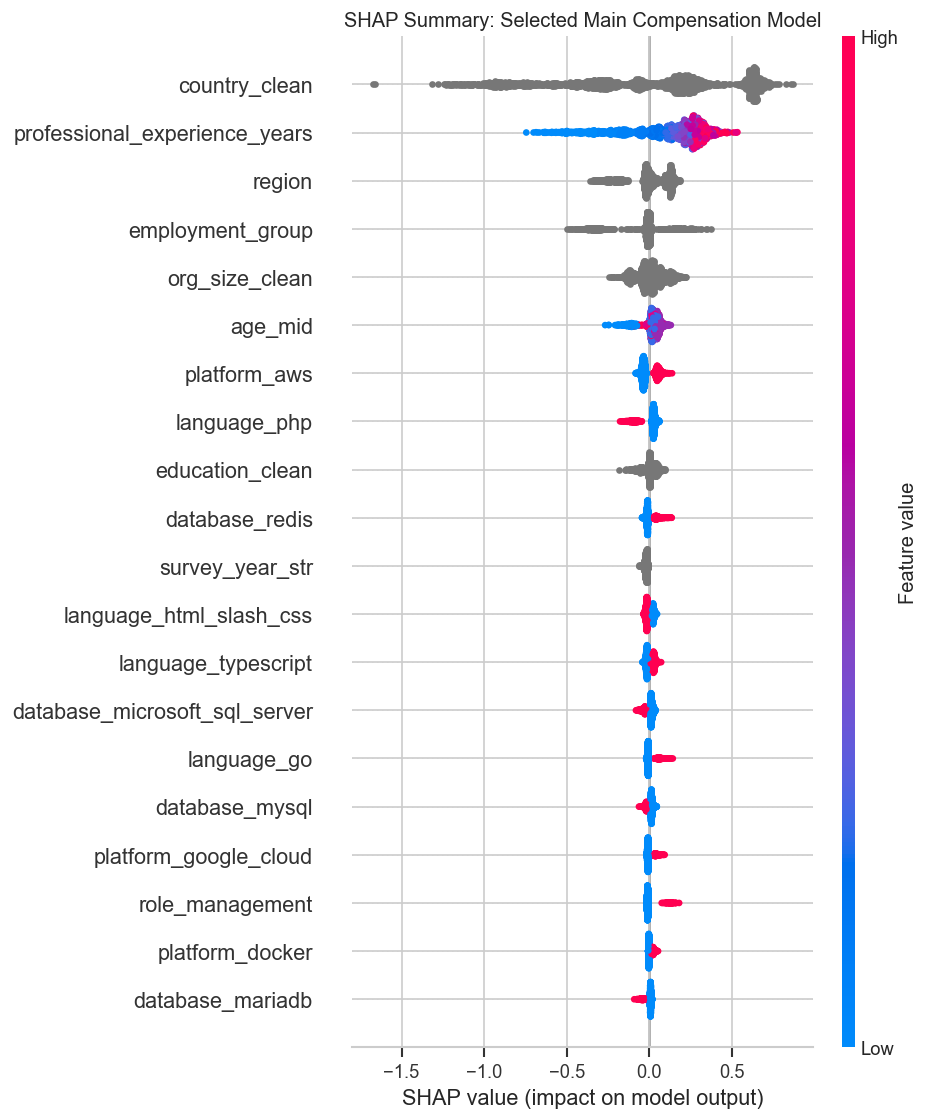

In [14]:
# Select the best performing model and display its metrics
selected_main = lightgbm_models[('tuned', 'core_winsor_top_tech')]
selected_main_metrics = pd.DataFrame([
    result_row('LightGBM winsorized target + top tech flags [tuned]', selected_main)
])
display(selected_main_metrics.round(2))

# Display the selected LightGBM parameters
print('Selected LightGBM parameters')
display(pd.DataFrame([selected_main['best_params']]))

plot_shap_summary(
    selected_main,
    'SHAP Summary: Selected Main Compensation Model',
    sample_size=2000,
    max_display=20
)

## Two-Stage Geography Backbone Plus Residuals Model

This is a lighter experimental branch. The first stage uses a geographic median backbone to absorb the large country-level shifts, then the second stage tries to explain the remaining compensation residuals with the other features.


In [15]:
# Test the lighter two-stage geography branch against the selected single-stage model
two_stage_result = fit_two_stage_lightgbm(
    core_train,
    core_valid,
    core_test,
    params=NOTEBOOK_TUNED_LGB_PARAMS
)

two_stage_summary = pd.DataFrame([
    result_row('Country-region median baseline', baseline_result),
    result_row('Selected single-stage LightGBM', selected_main),
    result_row('Two-stage LightGBM residual', two_stage_result)
]).sort_values('valid_medae_real')

display(two_stage_summary.round(2))

,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
1,Selected single-stage LightGBM,14811.30,17732.87,62915.47,0.57
2,Two-stage LightGBM residual,15977.57,18914.41,64031.69,0.55
0,Country-region median baseline,21836.51,23555.65,72858.83,0.43


## GDP PPP Corrected LightGBM Model

This is another experimental branch. GDP PPP is a rough way to account for the fact that the same converted salary does not buy the same thing in every country. The goal here is not to overcomplicate the main model, it is just to check whether that macro context adds enough signal to matter.


Merged GDP PPP sample


,country_clean,region,gdp_ppp,log_gdp_ppp
13508,Czechia,Europe,59021.572181,10.985658
43502,Sweden,Europe,67075.676272,11.113577
72388,United States,Americas,77860.911291,11.262679
175673,India,Asia,9207.127430,9.127733
142399,Brazil,Americas,19876.853353,9.897311


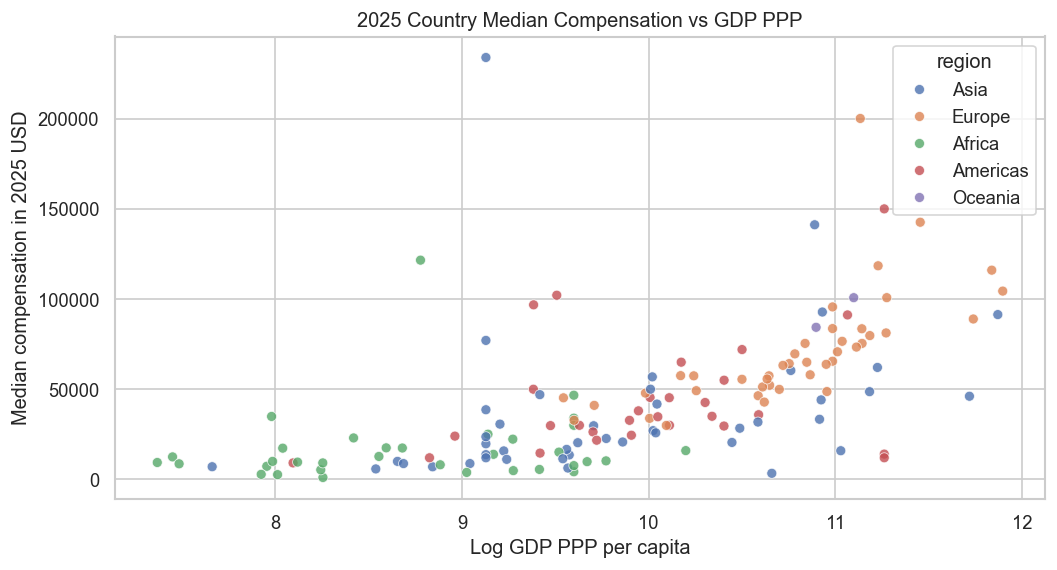

,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
1,GDP PPP LightGBM,14779.73,17834.76,62806.78,0.57
0,Selected main LightGBM,14811.30,17732.87,62915.47,0.57


In [16]:
wb_df = fetch_world_bank_gdp_ppp(year=2022)
core_macro_df = merge_gdp_ppp(core_df, wb_df)

print('Merged GDP PPP sample')
display(core_macro_df[['country_clean', 'region', 'gdp_ppp', 'log_gdp_ppp']].sample(5, random_state=RANDOM_STATE))

# Collapse to country-level medians for the test year to visualize the relationship between GDP PPP and compensation in 2025
macro_country_view = (
    core_macro_df.loc[core_macro_df['survey_year'] == TEST_YEAR]
    .groupby(['country_clean', 'region'], as_index=False)
    .agg(
        median_comp_real_2025=(COMP_REAL, 'median'),
        log_gdp_ppp=('log_gdp_ppp', 'median')
    )
)

# Visualize the relationship between GDP PPP and median compensation in 2025 by country, colored by region
plt.figure(figsize=(10, 5))
sns.scatterplot(data=macro_country_view, x='log_gdp_ppp', y='median_comp_real_2025', hue='region', alpha=0.8)
plt.title('2025 Country Median Compensation vs GDP PPP')
plt.xlabel('Log GDP PPP per capita')
plt.ylabel('Median compensation in 2025 USD')
plt.show()

# LightGBM model using the macro-enhanced dataset to see if GDP PPP helps improve predictions
macro_result = fit_window_lightgbm(
    core_macro_df,
    CORE_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    CORE_CAT,
    CORE_NUM + ['log_gdp_ppp'],
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=True
)

macro_summary = pd.DataFrame([
    result_row('Selected main LightGBM', selected_main),
    result_row('GDP PPP LightGBM', macro_result)
]).sort_values('valid_medae_real')
display(macro_summary.round(2))

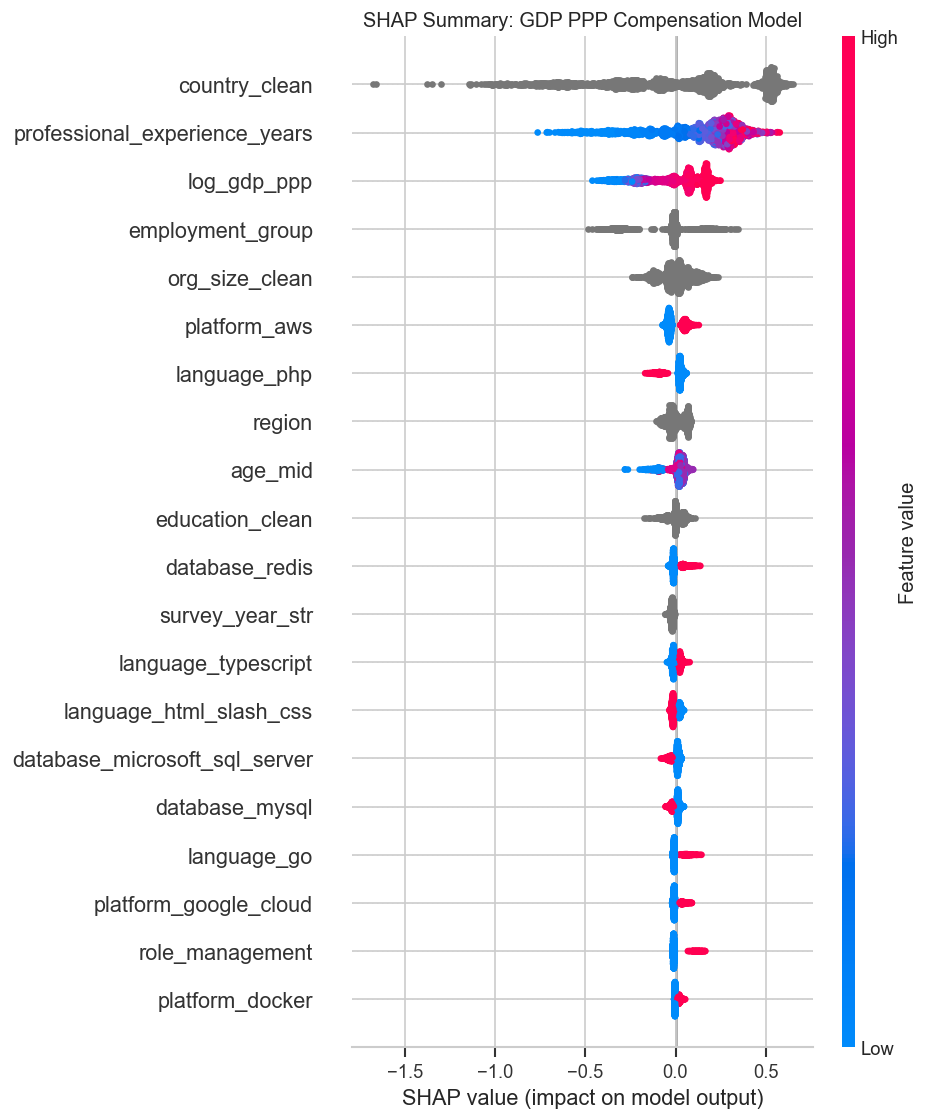

In [17]:
# Show SHAP for the GDP PPP branch so it can be compared to the main model
plot_shap_summary(
    macro_result,
    'SHAP Summary: GDP PPP Compensation Model',
    sample_size=2000,
    max_display=20
)

## Locked Country / Region LightGBM Models

Geography dominates compensation modeling, so it is worth checking what happens once the model is locked inside a country or region. This helps show whether the fit gets better within a geography and what features matter once the cross-country compensation gap is taken out of the picture.


In [18]:
geo_models = {}
geo_rows = []

# Fits and evaluates separate LightGBM model for each locked geography
for geo_type, geo_name in FOCUS_GEOS:
    geo_result = fit_locked_geography_model(core_df, geo_type, geo_name, params=NOTEBOOK_TUNED_LGB_PARAMS)
    if geo_result is None:
        continue
    geo_models[(geo_type, geo_name)] = geo_result
    geo_rows.append({
        'geo_type': geo_type,
        'geo_name': geo_name,
        'train_rows': geo_result['train_rows'],
        'valid_rows': geo_result['valid_rows'],
        'test_rows': geo_result['test_rows'],
        'valid_medae_real': geo_result['valid_metrics']['medae_real'],
        'test_medae_real': geo_result['test_metrics']['medae_real'],
        'test_rmse_real': geo_result['test_metrics']['rmse_real'],
        'test_r2_log': geo_result['test_metrics']['r2_log']
    })

geo_summary = pd.DataFrame(geo_rows).sort_values('valid_medae_real')
display(geo_summary.round(2))

,geo_type,geo_name,train_rows,valid_rows,test_rows,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
1,country,India,13470,966,926,6271.99,8221.30,55738.69,0.39
2,region,Europe,89621,10937,10216,12777.31,15249.14,48300.55,0.37
0,country,United States,46123,4232,4372,30483.38,34933.93,93029.86,0.30


Country: United States


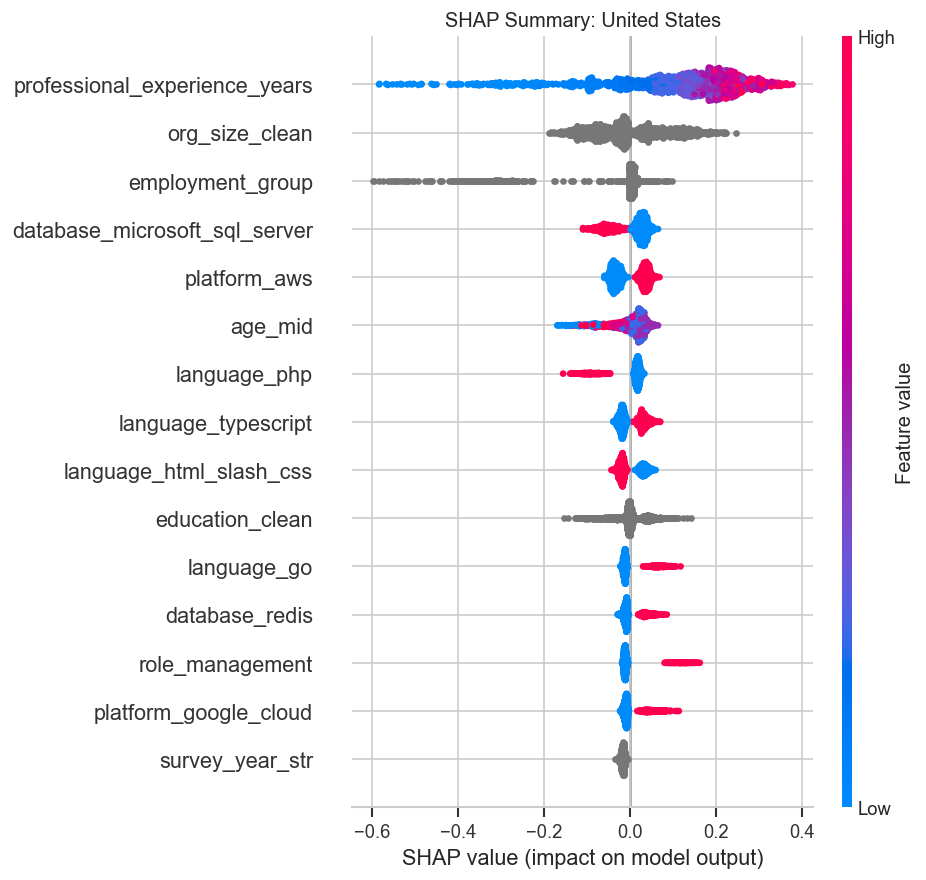

Country: India


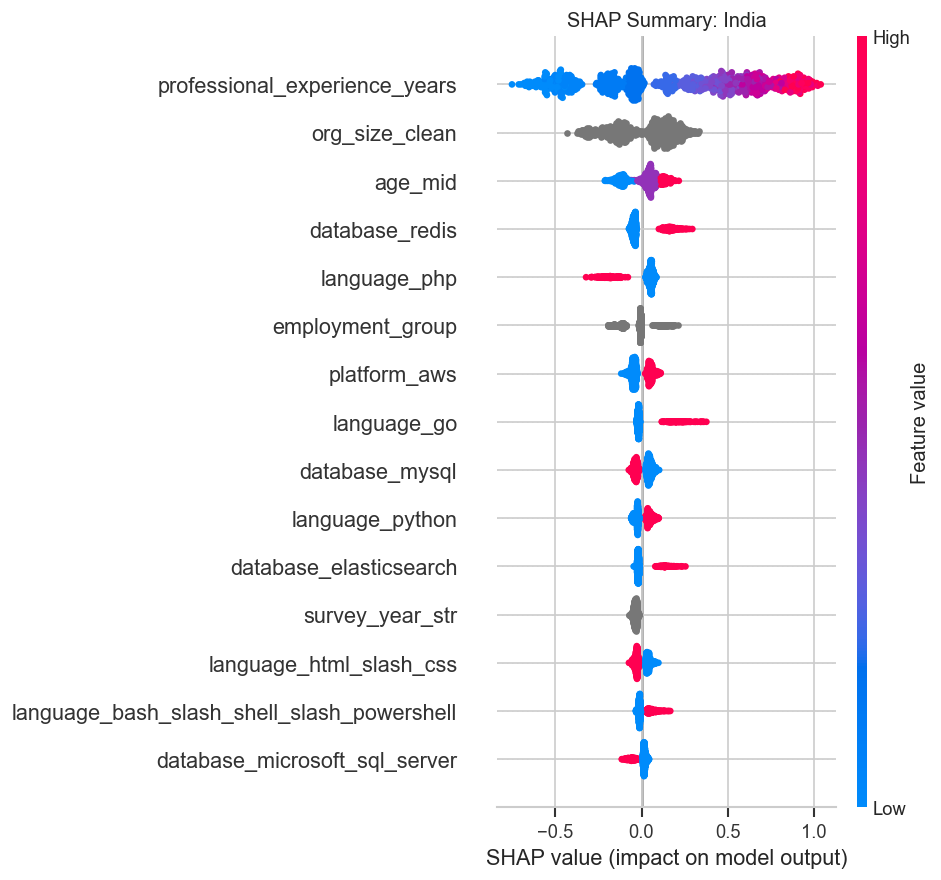

Region: Europe


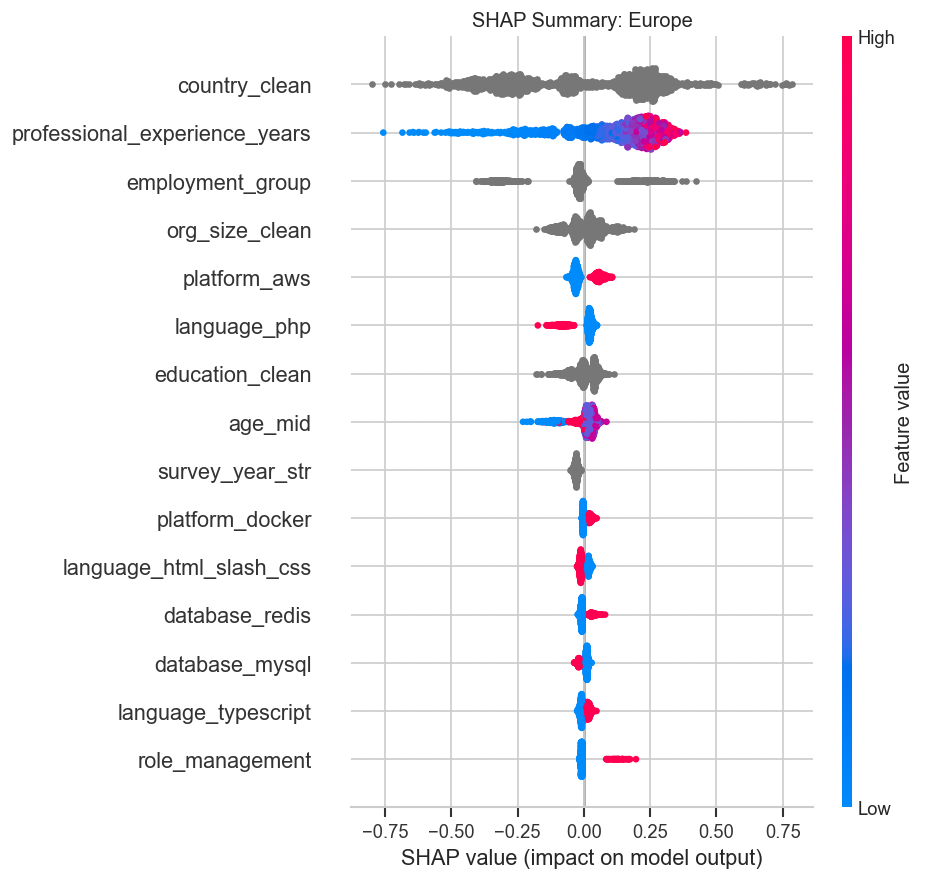

In [19]:
# Show SHAP for each locked geography fit to see what changes once location is fixed
for geo_type, geo_name in FOCUS_GEOS:
    key = (geo_type, geo_name)
    if key not in geo_models:
        continue
    print(f'{geo_type.title()}: {geo_name}')
    plot_shap_summary(
        geo_models[key],
        f'SHAP Summary: {geo_name}',
        sample_size=1500,
        max_display=15
    )

## Rolling-Origin Check

This is the final stability check for the selected model. I do not want to retune every branch across every possible split, but I do want to see whether the chosen model stays competitive as the training window expands over time.


In [20]:
rolling_rows = []

# Fits LightGBM and Ridge models on multiple rolling origin splits to evaluate stability of performance across different training and validation years
for train_years, valid_year, train_fold, valid_fold in rolling_origin_splits(core_df, min_train_year=2019, final_valid_year=2024):
    ridge_fold = fit_ridge_holdout(train_fold, valid_fold, valid_fold, CORE_CAT, CORE_NUM, alphas=[25.0])
    plain_fold = fit_window_lightgbm(
        pd.concat([train_fold, valid_fold], axis=0),
        train_years,
        valid_year,
        valid_year,
        CORE_CAT,
        CORE_NUM,
        params=NOTEBOOK_TUNED_LGB_PARAMS,
        use_top_tech=True,
        winsor_target=False
    )
    winsor_fold = fit_window_lightgbm(
        pd.concat([train_fold, valid_fold], axis=0),
        train_years,
        valid_year,
        valid_year,
        CORE_CAT,
        CORE_NUM,
        params=NOTEBOOK_TUNED_LGB_PARAMS,
        use_top_tech=True,
        winsor_target=True
    )

    rolling_rows.extend([
        {
            'setup': 'Ridge core alpha=25.0',
            'train_years': ','.join(map(str, train_years)),
            'valid_year': valid_year,
            **ridge_fold['valid_metrics']
        },
        {
            'setup': 'LightGBM core + top tech flags [tuned]',
            'train_years': ','.join(map(str, train_years)),
            'valid_year': valid_year,
            **plain_fold['valid_metrics']
        },
        {
            'setup': 'LightGBM winsorized target + top tech flags [tuned]',
            'train_years': ','.join(map(str, train_years)),
            'valid_year': valid_year,
            **winsor_fold['valid_metrics']
        }
    ])

rolling_df = pd.DataFrame(rolling_rows)
rolling_summary = (
    rolling_df
    .groupby('setup', as_index=False)
    .agg(
        fold_count=('valid_year', 'size'),
        mean_valid_medae_real=('medae_real', 'mean'),
        mean_valid_rmse_real=('rmse_real', 'mean'),
        mean_valid_r2_log=('r2_log', 'mean')
    )
    .sort_values('mean_valid_medae_real')
)

display(rolling_summary.round(2))

KeyboardInterrupt: 

## Next Steps

- wire the selected model logic into `src/compensation_modeling.py` as the canonical implementation
- keep the tuned LightGBM family as the benchmark for any future compensation changes
- keep the GDP PPP, locked-geography, and two-stage branches as side analyses since they did not improve enough to justify the extra complexity


# Feature Importance Ranking & Prediction Error by Country

Extract feature importances from the selected LightGBM model. And prediction errors for the test set by country


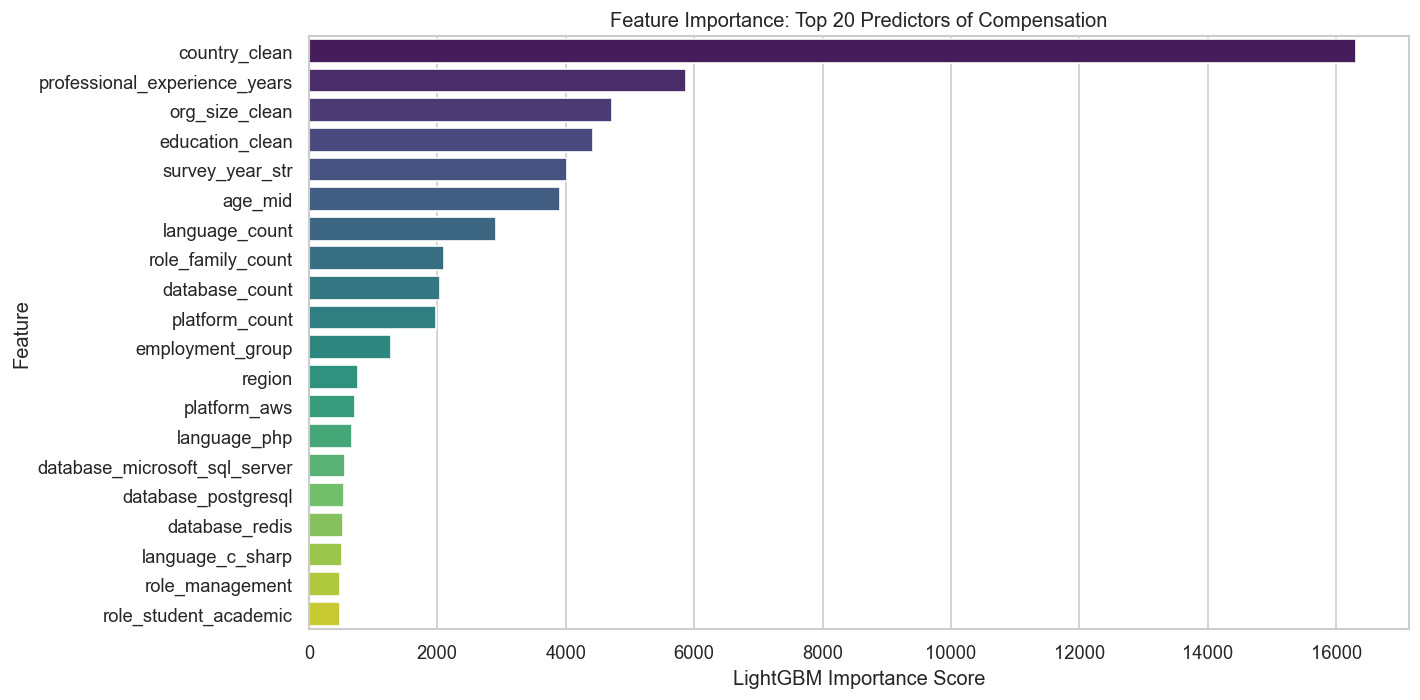

Top 20 Feature Importances


,feature,importance
2,country_clean,16316
7,professional_experience_years,5870
5,org_size_clean,4722
4,education_clean,4423
0,survey_year_str,4023
6,age_mid,3913
8,language_count,2913
19,role_family_count,2101
9,database_count,2033
10,platform_count,1971


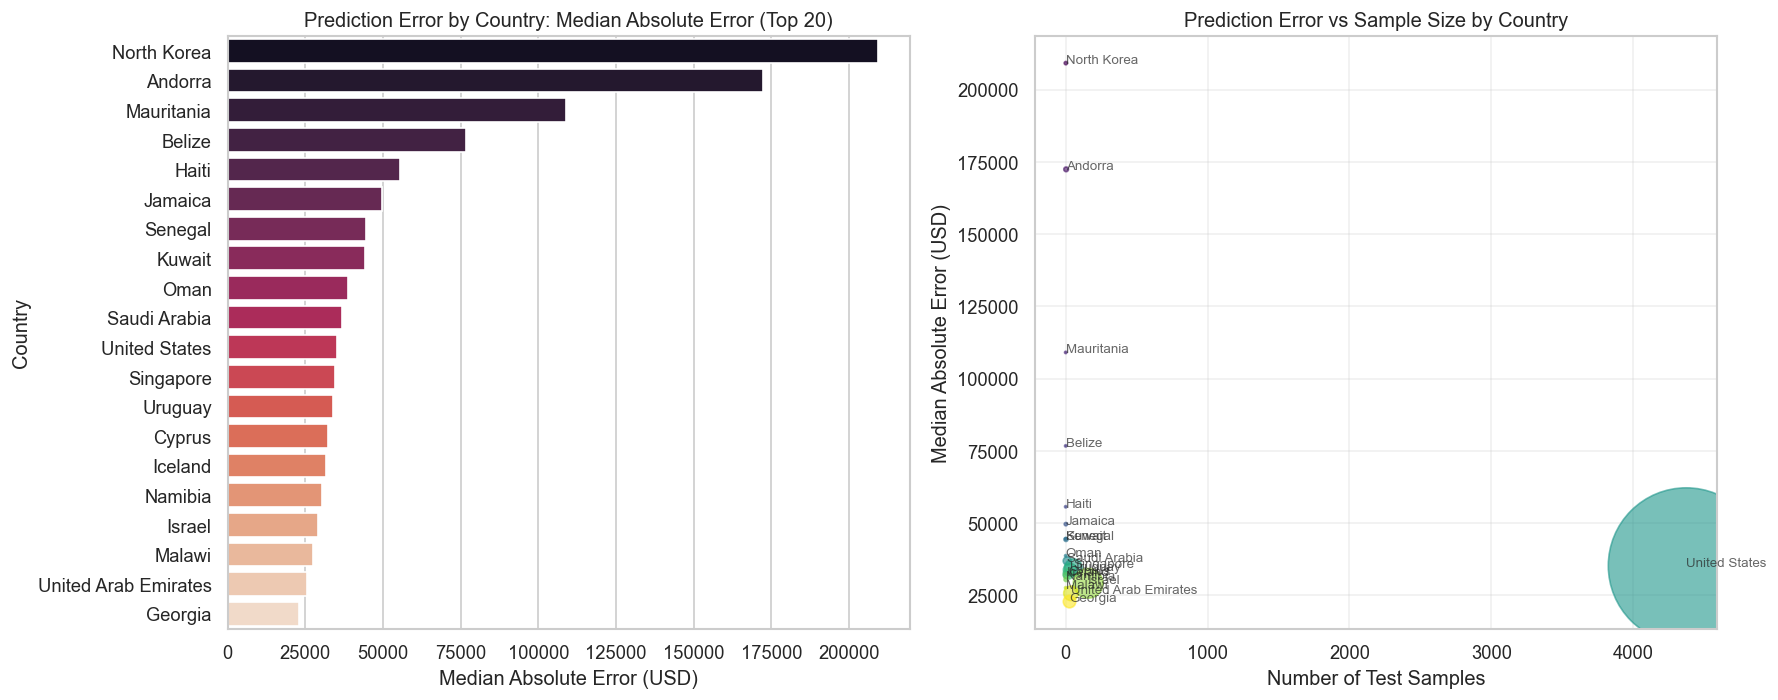

Prediction Error by Country (Top 20 by Error)


,country_clean,count,median_abs_error,mean_abs_error,rmse,median_pct_error
100,North Korea,2,209181.64,209181.64,293708.76,53.15
3,Andorra,4,172429.85,154308.36,173887.36,65.49
85,Mauritania,1,109067.95,109067.95,109067.95,89.72
15,Belize,1,76727.12,76727.12,76727.12,75.13
52,Haiti,1,55663.55,55663.55,55663.55,608.41
65,Jamaica,2,49648.84,49648.84,57137.46,46.83
116,Senegal,1,44562.33,44562.33,44562.33,193.77
71,Kuwait,3,44360.10,38579.80,42616.53,171.78
103,Oman,1,38717.55,38717.55,38717.55,1145.15
115,Saudi Arabia,12,36925.60,36303.54,44205.02,49.66


In [ ]:
selected_model = selected_main['model']
feature_importance_df = pd.DataFrame({
    'feature': selected_main['feature_cols'],
    'importance': selected_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance: Top 20 Predictors of Compensation')
plt.xlabel('LightGBM Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top 20 Feature Importances')
display(feature_importance_df.round(4))


# Prediction Error by Country
# Calculate prediction errors for the test set by country
test_results = selected_main['test_df'].copy()
test_results['pred_log'] = selected_main['test_pred']
test_results['pred_real'] = np.exp(selected_main['test_pred'])
test_results['actual_real'] = np.exp(test_results[COMP_TARGET])
test_results['abs_error'] = np.abs(test_results['actual_real'] - test_results['pred_real'])
test_results['pct_error'] = np.abs(test_results['actual_real'] - test_results['pred_real']) / test_results['actual_real'] * 100

# Group by country and calculate error metrics
country_error_df = (
    test_results
    .groupby('country_clean', as_index=False)
    .agg(
        count=('abs_error', 'size'),
        median_abs_error=('abs_error', 'median'),
        mean_abs_error=('abs_error', 'mean'),
        rmse=('abs_error', lambda x: np.sqrt(np.mean(x**2))),
        median_pct_error=('pct_error', 'median')
    )
    .sort_values('median_abs_error', ascending=False)
    .head(20)  # Top 20 countries with highest errors
)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Median absolute error by country
sns.barplot(data=country_error_df, x='median_abs_error', y='country_clean', ax=axes[0], palette='rocket')
axes[0].set_title('Prediction Error by Country: Median Absolute Error (Top 20)')
axes[0].set_xlabel('Median Absolute Error (USD)')
axes[0].set_ylabel('Country')

# Right plot: Sample size and error together
ax2 = axes[1]
scatter = ax2.scatter(country_error_df['count'], country_error_df['median_abs_error'], 
                     s=country_error_df['count']*2, alpha=0.6, c=range(len(country_error_df)), cmap='viridis')
for idx, row in country_error_df.iterrows():
    ax2.annotate(row['country_clean'], 
                (row['count'], row['median_abs_error']), 
                fontsize=8, alpha=0.7)
ax2.set_xlabel('Number of Test Samples')
ax2.set_ylabel('Median Absolute Error (USD)')
ax2.set_title('Prediction Error vs Sample Size by Country')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Prediction Error by Country (Top 20 by Error)')
display(country_error_df.round(2))